In [1]:
!pip install langchain-groq langgraph langchain-community duckduckgo-search -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
!pip install -U ddgs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 8.9 MB/s eta 0:00:00


In [3]:
from google.colab import userdata
my_api_key = userdata.get('groq_api')

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model='llama-3.3-70b-versatile',
    temperature=0,
    api_key=my_api_key
)

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    print("⭐ multiply() called")
    return a * b

tools = [search, multiply]
llm_with_tools = llm.bind_tools(tools)

/tmp/ipykernel_1735/1915391003.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [6]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

class State(TypedDict):
    messages: Annotated[list, add_messages]

def assistant_node(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

def should_continue(state: State) -> Literal["tools", END]:
    if state["messages"][-1].tool_calls:
        return "tools"
    return END

In [ ]:
# Without HITL — agent acts immediately, no pause
builder = StateGraph(State)
builder.add_node("assistant", assistant_node)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", should_continue)
builder.add_edge("tools", "assistant")

graph_no_hitl = builder.compile(checkpointer=MemorySaver())

In [ ]:
# Agent runs the tool immediately — no chance to stop it
config = {"configurable": {"thread_id": "no_hitl"}}
result = graph_no_hitl.invoke(
    {"messages": [("user", "What is 952124 * 123991?")]},
    config=config
)
print(result["messages"][-1].content)
# Tool ran. You had no say.

⭐ multiply() called
The result of 952124 * 123991 is 118054806884.


In [ ]:
# Without HITL — agent acts immediately, no pause
builder = StateGraph(State)
builder.add_node("assistant", assistant_node)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", should_continue)
builder.add_edge("tools", "assistant")

graph_hitl = builder.compile(
    checkpointer=MemorySaver(),
    interrupt_before = ['tools']
)

In [ ]:
# Agent runs the tool immediately — no chance to stop it
config = {"configurable": {"thread_id": "hitl_test"}}
result = graph_hitl.invoke(
    {"messages": [("user", "What is 952124 * 123991?")]},
    config=config
)
print(result["messages"][-1].tool_calls)

[{'name': 'multiply', 'args': {'a': 952124, 'b': 123991}, 'id': 'phk8hg6gf', 'type': 'tool_call'}]


In [ ]:
# Human approves - call the invoke again with None
# None means : 'no new message, just continue from where you stopped'
final = graph_hitl.invoke(None, config=config)

final['messages'][-1].content

# If you don't call it again, then it is rejected

⭐ multiply() called


'The result of 952124 * 123991 is 118054806884.'

In [ ]:
# Approve or Reject with input() -> will type Yes or No

def run_with_approval(user_message: str, thread_id: str):
    config = {'configurable': {"thread_id": thread_id}}

    result = graph_hitl.invoke(
        {"messages": [("user", user_message)]},
        config = config
    )

    last = result['messages'][-1]

    if not last.tool_calls:
        print('Agent answered directly (no tool needed)')
        print(last.content)
        return

    else:
        tool_call = last.tool_calls[0]
        print('Agent wants to use a tool')
        print('Tool: ', tool_call['name'])
        print('Args: ', tool_call['args'])

        decision = input('Approve? (yes/no): ').strip().lower()

        if decision == 'yes':
            final = graph_hitl.invoke(None, config=config)
            print("\n✅ Approved. Agent continued.")
            print("Answer:", final["messages"][-1].content)
        else:
            print("\n❌ Rejected. Agent was stopped. No action taken.")

In [ ]:
run_with_approval('What is 12 * 99?', thread_id = 'approval_1')

Agent wants to use a tool
Tool:  multiply
Args:  {'a': 12, 'b': 99}
Approve? (yes/no): Yes
⭐ multiply() called

✅ Approved. Agent continued.
Answer: The result of 12 * 99 is 1188.


In [ ]:
run_with_approval('What is 12 * 99?', thread_id = 'approval_reject')

Agent wants to use a tool
Tool:  multiply
Args:  {'a': 12, 'b': 99}
Approve? (yes/no): No

❌ Rejected. Agent was stopped. No action taken.


# Reflection and Self-Critique Agent

In [8]:
!pip install langchain-groq langgraph -q

In [ ]:
from google.colab import userdata
my_api_key = userdata.get('groq_api')

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model='llama-3.3-70b-versatile',
    temperature=0,
    api_key=my_api_key
)

In [ ]:
# The core idea - Writer and Critic (Reviewer)

# Step 1: Writer generates something
writer_prompt = 'Write a 3 sentence explanation of what a neural network is.'

draft = llm.invoke(writer_prompt).content

print(draft)

A neural network is a computer system inspired by the structure and function of the human brain, consisting of layers of interconnected nodes or "neurons" that process and transmit information. These nodes receive input data, perform complex calculations, and produce output signals that are then passed on to subsequent layers, allowing the network to learn and make decisions based on patterns in the data. Through a process of training and optimization, neural networks can be taught to perform a wide range of tasks, such as image recognition, natural language processing, and predictive modeling, making them a powerful tool in the field of artificial intelligence.


In [ ]:
# Step 2: Critic looks at the draft and gives feedback
critic_prompt = f'''You are a harsh but fair critic. Read the draft below and give specific feedback on how to
                    improve it. Point out what is unclear, too vague or missing

                    Draft:
                    {draft}

                    Give feedback only. Do not rewrite it.'''

feedback = llm.invoke(critic_prompt).content

print(feedback)

The draft provides a good introduction to neural networks, but there are areas that need improvement for clarity and specificity. 

One issue is that the term "complex calculations" is too vague - it would be helpful to provide more details about the type of calculations being performed, such as linear transformations or activation functions. 

Additionally, the phrase "patterns in the data" is somewhat unclear - what kind of patterns are being referred to? Are they statistical patterns, spatial patterns, or something else? Providing more context or specificity about the types of patterns being learned would strengthen the draft.

The sentence structure is also quite long and convoluted, which can make it difficult to follow - consider breaking up the sentences into shorter, simpler ones to improve readability.

The draft also lacks concrete examples or applications of neural networks beyond general categories like "image recognition" and "natural language processing". Adding specific 

In [ ]:
# Step 3: Writer improves the draft on the basis of the feedback given

improve_prompt = f'''You are a writer. You wrote a draft and received feedback.
                    Rewrite the draft by addressing all the feedback points.draft

                    Original draft:
                    {draft}

                    Feedback:
                    {feedback}

                    Write the improved version only.'''

improved = llm.invoke(improve_prompt).content

print(improved)

A neural network is a computer system inspired by the structure and function of the human brain. It consists of layers of interconnected nodes or "neurons" that process and transmit information. These nodes receive input data and perform specific calculations, such as linear transformations and activation functions, to extract relevant features from the data.

Through this process, neural networks can learn to recognize patterns in the data, including statistical patterns, spatial patterns, and temporal patterns. For example, in image recognition, a neural network might learn to identify patterns of edges, shapes, and textures that distinguish one object from another. In natural language processing, a neural network might learn to recognize patterns of language syntax and semantics to generate human-like text.

Neural networks can be trained to perform a wide range of tasks, including image recognition, natural language processing, and predictive modeling. For instance, neural networks

In [7]:
# Build properly using Langgraph

from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END

In [ ]:
# State now tracks the draft and the feedback separately
class State(TypedDict):
    messages: Annotated[list, add_messages]
    draft: str
    feedback: str
    round_number: int

In [ ]:
def writer_node(state:State):
    round_num = state.get('round_number', 0)

    if round_num == 0:
        user_request = state['messages'][-1].content
        prompt = f'Write a clear 3-4 sentence explanation of: {user_request}'

    else:
        prompt = f'''Improve this draft based on the feedback below.
                     Write the improved version only. No preamble.

                     Draft:
                     {state['draft']}

                     Feedback:
                     {state['feedback']}'''


    draft = llm.invoke(prompt).content

    print(f"\n✏️  Writer (round {round_num + 1}):\n{draft}")

    return {'draft': draft, 'round_number': round_num + 1}

In [ ]:
def critic_node(state: State):
    draft = state['draft']

    prompt = f'''You are a strict critic. Read this draft carefully.

                Draft:
                {draft}

                If the draft is clear, accurate and complete - response with exactly: APPROVED

                If it needs improvement - respond with: NEEDS WORK: (then your specific feedback on one line)
                '''

    feedback = llm.invoke(prompt).content

    print(f"\n🔍 Critic (round {state['round_number']}):\n{feedback}")
    return {"feedback": feedback}

In [ ]:
def should_continue(state: State) -> Literal['writer', END]:
    feedback = state['feedback']
    round_number = state['round_number']

    if "APPROVED" in feedback or round_number >= 3:
        print("\n✅ Critic approved. Stopping.")
        return END

    else:
        print("\n🔁 Critic not satisfied. Sending back to writer.")
        return "writer"

In [ ]:
builder = StateGraph(State)

builder.add_node('writer', writer_node)
builder.add_node('critic', critic_node)

builder.add_edge(START, 'writer')
builder.add_edge('writer', 'critic')
builder.add_conditional_edges('critic', should_continue)

reflection_graph = builder.compile()

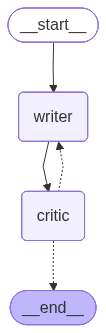

In [ ]:
reflection_graph

In [ ]:
# TEST ITTTTT

result = reflection_graph.invoke({
    "messages": [("user", "What is a large language model")],
    "draft": "",
    "feedback": "",
    "round_number": 0
})

print(result['draft'])


✏️  Writer (round 1):
A large language model is a type of artificial intelligence (AI) designed to process and understand human language at a massive scale. These models are trained on vast amounts of text data, allowing them to learn patterns, relationships, and nuances of language, and generate human-like responses to a wide range of questions and prompts. By leveraging complex algorithms and neural networks, large language models can comprehend and respond to natural language inputs, enabling applications such as chatbots, language translation, and text summarization. This technology has the potential to revolutionize the way we interact with machines and access information.

🔍 Critic (round 1):
NEEDS WORK: The draft lacks specific examples and technical details to support its claims, making it more of a general overview than a comprehensive explanation of large language models.

🔁 Critic not satisfied. Sending back to writer.

✏️  Writer (round 2):
A large language model is a type

In [ ]:
# Challenge 1 (Easy)
# Change the writer's task from explanation writing to writing a tweet (max 280 characters) about any tech topic.
# The critic should check if it is under 280 characters and engaging. Run the reflection graph and see how it improves.

In [ ]:
def writer_node(state:State):
    round_num = state.get('round_number', 0)

    if round_num == 0:
        user_request = state['messages'][-1].content
        prompt = f'Write a tweet of maximum 280 characters: {user_request}'

    else:
        prompt = f'''Improve this draft based on the feedback below.
                     Write the improved version only. No preamble.

                     Draft:
                     {state['draft']}

                     Feedback:
                     {state['feedback']}'''


    draft = llm.invoke(prompt).content

    print(f"\n✏️  Writer (round {round_num + 1}):\n{draft}")

    return {'draft': draft, 'round_number': round_num + 1}

In [ ]:
def critic_node(state: State):
    draft = state['draft']

    prompt = f'''You are a strict critic. Read this draft carefully. Draft should be under 280 characters and engaging.

                Draft:
                {draft}

                If the draft is clear, accurate and complete - response with exactly: APPROVED

                If it needs improvement - respond with: NEEDS WORK: (then your specific feedback on one line)
                '''

    feedback = llm.invoke(prompt).content

    print(f"\n🔍 Critic (round {state['round_number']}):\n{feedback}")
    return {"feedback": feedback}

In [ ]:
def should_continue(state: State) -> Literal['writer', END]:
    feedback = state['feedback']
    round_number = state['round_number']

    if "APPROVED" in feedback or round_number >= 3:
        print("\n✅ Critic approved. Stopping.")
        return END

    else:
        print("\n🔁 Critic not satisfied. Sending back to writer.")
        return "writer"

In [ ]:
builder = StateGraph(State)

builder.add_node('writer', writer_node)
builder.add_node('critic', critic_node)

builder.add_edge(START, 'writer')
builder.add_edge('writer', 'critic')
builder.add_conditional_edges('critic', should_continue)

reflection_graph = builder.compile()

In [ ]:
# TEST ITTTTT

result = reflection_graph.invoke({
    "messages": [("user", "What is agentic AI")],
    "draft": "",
    "feedback": "",
    "round_number": 0
})

print(result['draft'])


✏️  Writer (round 1):
"Agentic AI: AI systems that can act autonomously, making decisions & taking actions to achieve goals, with a sense of agency & self-directed purpose #AgenticAI #ArtificialIntelligence"

🔍 Critic (round 1):
NEEDS WORK: Consider shortening "with a sense of agency & self-directed purpose" to make it more concise, as the draft is slightly over 280 characters when including the hashtags.

🔁 Critic not satisfied. Sending back to writer.

✏️  Writer (round 2):
"Agentic AI: AI systems that can act autonomously, making decisions & taking actions to achieve goals, with self-directed purpose #AgenticAI #ArtificialIntelligence"

🔍 Critic (round 2):
NEEDS WORK: Consider shortening "self-directed purpose" to make the tweet more concise, such as "Agentic AI: AI systems acting autonomously to achieve goals #AgenticAI #ArtificialIntelligence"

🔁 Critic not satisfied. Sending back to writer.

✏️  Writer (round 3):
"Agentic AI: AI systems acting autonomously to achieve goals #Agen

In [ ]:
# Challenge 2 (Medium)
# Build a reflection graph for code writing.
# The writer writes a Python function.
# The critic checks if it has a docstring, handles edge cases, and is readable.
# Loop until the critic approves.

In [ ]:
def writer_node(state:State):
    round_num = state.get('round_number', 0)

    if round_num == 0:
        user_request = state['messages'][-1].content
        prompt = f'Write a python program on: {user_request}'

    else:
        prompt = f'''Improve this draft based on the feedback below.
                     Write the improved version only. No preamble.

                     Draft:
                     {state['draft']}

                     Feedback:
                     {state['feedback']}'''


    draft = llm.invoke(prompt).content

    print(f"\n✏️  Writer (round {round_num + 1}):\n{draft}")

    return {'draft': draft, 'round_number': round_num + 1}

In [ ]:
def critic_node(state: State):
    draft = state['draft']

    prompt = f'''You are a strict critic. Read this draft carefully. Draft should have docstring, handle edge cases and is readable.

                Draft:
                {draft}

                If the draft is clear, accurate and complete - response with exactly: APPROVED

                If it needs improvement - respond with: NEEDS WORK: (then your specific feedback on one line)
                '''

    feedback = llm.invoke(prompt).content

    print(f"\n🔍 Critic (round {state['round_number']}):\n{feedback}")
    return {"feedback": feedback}

In [ ]:
def should_continue(state: State) -> Literal['writer', END]:
    feedback = state['feedback']
    round_number = state['round_number']

    if "APPROVED" in feedback or round_number >= 3:
        print("\n✅ Critic approved. Stopping.")
        return END

    else:
        print("\n🔁 Critic not satisfied. Sending back to writer.")
        return "writer"

In [ ]:
builder = StateGraph(State)

builder.add_node('writer', writer_node)
builder.add_node('critic', critic_node)

builder.add_edge(START, 'writer')
builder.add_edge('writer', 'critic')
builder.add_conditional_edges('critic', should_continue)

reflection_graph = builder.compile()

In [ ]:
# TEST ITTTTT

result = reflection_graph.invoke({
    "messages": [("user", "Write a function that takes user name and password, then do validation checks")],
    "draft": "",
    "feedback": "",
    "round_number": 0
})

print(result['draft'])


✏️  Writer (round 1):
**User Validation Program**

This program defines a function `validate_user` that takes a username and password as input, performs validation checks, and returns a boolean indicating whether the credentials are valid.

**Code**
```python
import re

def validate_user(username, password):
    """
    Validate a username and password.

    Args:
        username (str): The username to validate.
        password (str): The password to validate.

    Returns:
        bool: True if the credentials are valid, False otherwise.
    """
    # Define validation rules
    username_rules = [
        lambda x: len(x) >= 3,  # Username must be at least 3 characters long
        lambda x: len(x) <= 20,  # Username must be at most 20 characters long
        lambda x: re.match("^[a-zA-Z0-9_]+$", x)  # Username must only contain alphanumeric characters and underscores
    ]

    password_rules = [
        lambda x: len(x) >= 8,  # Password must be at least 8 characters long
       

In [ ]:
# Challenge 3 (Hard)
# Add a second critic — a "Simplicity Critic" that checks if the writing is easy to understand
# for a beginner. The draft must pass both critics (Content Critic AND Simplicity Critic)
# before it is accepted. If either rejects it, it goes back to the writer.

In [22]:
# State now tracks the draft and the feedback separately
class State(TypedDict):
    messages: Annotated[list, add_messages]
    draft: str
    content_feedback: str
    simplicity_feedback: str
    round_number: int

In [23]:
def writer_node(state:State):
    round_num = state.get('round_number', 0)

    if round_num == 0:
        user_request = state['messages'][-1].content
        prompt = f'Write a clear 3-4 sentence explanation of: {user_request}'

    else:
        prompt = f'''Improve this draft based on the feedback below.
                     Write the improved version only. No preamble.

                     Draft:
                     {state['draft']}

                     Content Feedback:
                     {state['content_feedback']}

                     Simplicity Feedback:
                     {state['simplicity_feedback']}'''


    draft = llm.invoke(prompt).content

    print(f"\n✏️  Writer (round {round_num + 1}):\n{draft}")

    return {'draft': draft, 'round_number': round_num + 1}

In [28]:
def critic_node(state: State):
    draft = state['draft']

    content_prompt = f'''You are a strict critic. Read this draft carefully.

                Draft:
                {draft}

                If the draft is clear, accurate and complete - response with exactly: APPROVED

                If it needs improvement - respond with:Content NEEDS WORK: (then your specific feedback on one line)
                '''


    simplicity_prompt = f'''You are a strict critic. Read this draft carefully.

                Draft:
                {draft}

                If the draft is easily understandable to beginner - response with exactly: APPROVED

                If it can be written in more simple words - respond with:Simplicity NEEDS WORK: (then your specific feedback on one line)
                '''

    content_feedback = llm.invoke(content_prompt).content
    simplicity_feedback = llm.invoke(simplicity_prompt).content

    print(f"\n🔍 Critic (round {state['round_number']}):")
    print(content_feedback)
    print('-'*80)
    print(simplicity_feedback)
    return {"content_feedback": content_feedback, "simplicity_feedback": simplicity_feedback}

In [29]:
def should_continue(state: State) -> Literal['writer', END]:
    content_feedback = state['content_feedback']
    simplicity_feedback = state['simplicity_feedback']
    round_number = state['round_number']

    if "APPROVED" in content_feedback and "APPROVED" in simplicity_feedback:
        print("\n✅ Critic approved. Stopping.")
        return END

    elif round_number >= 3:
        print("\n✅ Stopping. After round 3")
        return END

    else:
        print("\n🔁 Critic not satisfied. Sending back to writer.")
        return "writer"

In [30]:
builder = StateGraph(State)

builder.add_node('writer', writer_node)
builder.add_node('critic', critic_node)

builder.add_edge(START, 'writer')
builder.add_edge('writer', 'critic')
builder.add_conditional_edges('critic', should_continue)

reflection_graph = builder.compile()

In [31]:
# TEST ITTTTT

result = reflection_graph.invoke({
    "messages": [("user", "What is a large language model")],
    "draft": "",
    "content_feedback": "",
    "simplicity_feedback": "",
    "round_number": 0
})

print(result['draft'])


✏️  Writer (round 1):
A large language model is a type of artificial intelligence (AI) designed to process and understand human language at a large scale. These models are trained on vast amounts of text data, allowing them to learn patterns and relationships within language and generate human-like responses to a wide range of questions and prompts. By leveraging complex algorithms and massive datasets, large language models can perform tasks such as language translation, text summarization, and conversation generation with remarkable accuracy and coherence. This enables them to be used in various applications, including chatbots, virtual assistants, and language translation software.

🔍 Critic (round 1):
Content NEEDS WORK: The draft lacks specific examples and technical details to support its claims, and could benefit from a more nuanced explanation of the limitations and potential biases of large language models.
---------------------------------------------------------------------